In [ ]:
import json
import os
import random
import numpy as np
import pandas as pd
import csv
import cv2
import math 
from math import gcd
from IPython.display import HTML
from base64 import b64encode
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GCNConv
from torch.nn.modules.normalization import LayerNorm
import torch.nn.init as init
from torch.optim.lr_scheduler import StepLR
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from collections import Counter
from torch.utils.data import DataLoader, Subset, TensorDataset


In [16]:
n_part = 128       #Number of features per body part in higher dimensional space
n_graph_out = 16   #Number of output features from the GCN layer
n_rnn = 128        #Hidden size of the LSTM
n_rnn_out = 15     #Number of output features from the final BiRNN layer
DROPOUT = 0.3 # For dropout ablation tests

In [ ]:
def set_seeds(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seeds(42)

def read_json_file(file_path):
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
        return data
    except json.JSONDecodeError:
        print(f"Error reading JSON file: {file_path}")
        return None

def calculate_skip_and_keep(frame_rate, target_fps):
    """
    Calculate the number of frames to skip and the number of frames to keep based on the frame rate and target fps.

    Parameters:
    frame_rate (int): The original frame rate of the video.
    target_fps (int): The target frame rate after downsampling.

    Returns:
    skip_every_n (int): The number of frames to skip in each block.
    keep_every_m (int): The number of frames to keep in each block.
    """
    # Calculate the total frames in a block (skip + keep)
    total_frames_in_block = frame_rate

    # Calculate the number of frames to keep in each block
    keep_every_m = int((target_fps / frame_rate) * total_frames_in_block)

    # Calculate the number of frames to skip in each block
    skip_every_n = total_frames_in_block - keep_every_m

    return skip_every_n, keep_every_m


def create_step_pattern(frame_rate, target_fps):
    g = gcd(frame_rate, target_fps)
    cycle_len = frame_rate // g
    keep_count = target_fps // g
    remove_count = cycle_len - keep_count

    keeps_left = keep_count
    removes_left = remove_count
    cycle = []

    for i in range(cycle_len):
        if keeps_left == 0:
            cycle.append(False)
            removes_left -= 1
        elif removes_left == 0:
            cycle.append(True)
            keeps_left -= 1
        else:
            if i % 2 == 0:
                cycle.append(True)
                keeps_left -= 1
            else:
                cycle.append(False)
                removes_left -= 1

    repeats = frame_rate // cycle_len
    step_pattern = (cycle * repeats)[:frame_rate]

    return step_pattern

def process_openpose_output(directory, batch_size, frame_rate=25, target_fps=25, skip_every_n=0, keep_every_m=0, ignore_first_n=0):
    json_files = sorted([f for f in os.listdir(directory) if f.endswith('.json')])
    num_files = len(json_files)

    step_pattern = create_step_pattern(frame_rate, target_fps)

    selected_files = [f for i, f in enumerate(json_files[ignore_first_n:]) if step_pattern[i % frame_rate]]

    if len(selected_files) < (batch_size - 1) + 1:
        raise ValueError(f"Not enough files in the directory after applying the skip pattern. Found {len(selected_files)} files.")

    batches = [selected_files[i:i + batch_size] for i in range(0, len(selected_files), batch_size)]

    if len(batches[-1]) < batch_size:
        batches = batches[:-1]

    all_batches_data = []
    for batch in batches:
        batch_data = []
        for json_file in batch:
            file_path = os.path.join(directory, json_file)
            data = read_json_file(file_path)
            if data:
                batch_data.append(data)
        if batch_data:
            # Include the directory path with each batch
            all_batches_data.append((batch_data, batch, directory))

    return all_batches_data

frame_rate = 25  # Original FPS of the data
target_fps = 25  # Desired FPS
# Calculate skip and keep parameters dynamically
skip_every_n, keep_every_m = calculate_skip_and_keep(frame_rate, target_fps)

batch_size = 75  # Number of frames per batch

#Data augmentation to effectively double the dataset for more training examples.
def flip_keypoints_horizontally(keypoints, image_width=1):
    flipped_keypoints = keypoints.copy()
    flip_pairs = [
        (2, 5), (3, 6), (4, 7), (9, 12), (10, 13), (11, 14), (15, 16), (17, 18), (19, 22), (20, 23), (21, 24)
    ]

    for i in range(len(keypoints) // 3):
        if keypoints[i * 3] >= 0:
            flipped_keypoints[i * 3] = image_width - keypoints[i * 3]
        else:
            flipped_keypoints[i * 3] = keypoints[i * 3]

    for (i, j) in flip_pairs:
        flipped_keypoints[i * 3], flipped_keypoints[j * 3] = flipped_keypoints[j * 3], flipped_keypoints[i * 3]
        flipped_keypoints[i * 3 + 1], flipped_keypoints[j * 3 + 1] = flipped_keypoints[j * 3 + 1], flipped_keypoints[i * 3 + 1]
        flipped_keypoints[i * 3 + 2], flipped_keypoints[j * 3 + 2] = flipped_keypoints[j * 3 + 2], flipped_keypoints[i * 3 + 2]

    return flipped_keypoints

def add_noise_augmentation(keypoints, noise_std=0.005):
    pts = np.array(keypoints, dtype=np.float32).reshape(-1, 3).copy()
    visible = pts[:, 2] > 0

    if np.any(visible):
        noise = np.random.normal(0.0, noise_std, size=(pts.shape[0], 2)).astype(np.float32)
        pts[visible, :2] += noise[visible]

    return pts.reshape(-1).tolist()

def joint_dropout_augmentation(keypoints, dropout_prob=0.02):
    pts = np.array(keypoints, dtype=np.float32).reshape(-1, 3).copy()
    visible = pts[:, 2] > 0

    dropout_mask = (np.random.rand(pts.shape[0]) < dropout_prob) & visible
    pts[dropout_mask, 0] = -1
    pts[dropout_mask, 1] = -1
    pts[dropout_mask, 2] = 0

    return pts.reshape(-1).tolist()


def normalise_openpose_keypoints(keypoints):
    """normalise keypoints
    Takes the MidHip as the center and makes the shoulder width 1
    The skeleton is then rotated so the shoulders are horizontal
    any missing keypoints become NaN"""
    pts = np.array(keypoints, dtype=float).reshape(-1,3)
    xy = pts[:,:2]

    xy[xy < 0] = np.nan

    L_sh = xy[5]
    R_sh = xy[2]
    MidHip = xy[8]

    if np.isnan(L_sh).any() or np.isnan(R_sh).any() or np.isnan(MidHip).any():
        return keypoints

    xy_centered = xy - MidHip

    shoulder_width = np.linalg.norm(R_sh - L_sh)
    if shoulder_width < 1e-4:
        shoulder_width = 1.0
    xy_centered /= shoulder_width

    vec = R_sh - L_sh
    theta = -np.arctan2(vec[1], vec[0])
    
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta), np.cos(theta)]])
    
    xy_rot = np.dot(xy_centered, R.T)
    
    pts[:, :2] = xy_rot
    
    return pts.reshape(-1).tolist()


#Making a spatiotemporal matrix - Rows are body parts, columns are timesteps in a video.
def create_matrix(data, selected_files, augment=False):
    num_frames = len(selected_files)
    matrix = [[None] * num_frames for _ in range(len(body_parts))]

    for frame_number, (frame_data, json_file) in enumerate(zip(data, selected_files)):
        if frame_data['people']:
            keypoints = frame_data['people'][0]['pose_keypoints_2d']

            if augment:
                keypoints = [
                            flip_keypoints_horizontally(keypoints)
                            # add_noise_augmentation(keypoints),
                            # joint_dropout_augmentation(keypoints)
                            ]
            
            keypoints = normalise_openpose_keypoints(keypoints)

            if len(keypoints) == len(body_parts) * 1.5:
                for i in range(len(body_parts) // 2):
                    x, y, confidence = keypoints[i * 3:(i + 1) * 3]

                    if confidence > 0:
                        matrix[i * 2][frame_number] = x
                        matrix[i * 2 + 1][frame_number] = y
                    else:
                        matrix[i * 2][frame_number] = -1
                        matrix[i * 2 + 1][frame_number] = -1
            else:
                for i in range(len(body_parts) // 2):
                    matrix[i * 2][frame_number] = None
                    matrix[i * 2 + 1][frame_number] = None
        else:
            for i in range(len(body_parts) // 2):
                matrix[i * 2][frame_number] = None
                matrix[i * 2 + 1][frame_number] = None

    column_labels = [f'Frame_{os.path.splitext(f)[0]}' for f in selected_files]
    df = pd.DataFrame(matrix, index=row_labels, columns=column_labels)
    df.fillna(-1, inplace=True)

    return df

#From OpenPose "Body_25"
body_parts = [
    "x_Nose", "y_Nose", "x_Neck", "y_Neck", "x_RShoulder", "y_RShoulder", "x_RElbow", "y_RElbow", "x_RWrist", "y_RWrist",
    "x_LShoulder", "y_LShoulder", "x_LElbow", "y_LElbow", "x_LWrist", "y_LWrist", "x_MidHip", "y_MidHip", "x_RHip", "y_RHip",
    "x_RKnee", "y_RKnee", "x_RAnkle", "y_RAnkle", "x_LHip", "y_LHip", "x_LKnee", "y_LKnee", "x_LAnkle", "y_LAnkle",
    "x_REye", "y_REye", "x_LEye", "y_LEye", "x_REar", "y_REar", "x_LEar", "y_LEar", "x_LBigToe", "y_LBigToe",
    "x_LSmallToe", "y_LSmallToe", "x_LHeel", "y_LHeel", "x_RBigToe", "y_RBigToe", "x_RSmallToe", "y_RSmallToe", "x_RHeel", "y_RHeel"
]

row_labels = body_parts


"""I have added the below in to allow the user to use local data instead of google colab. It also allows for editting of how many sets 
of data that are used easier."""


base_path = "" # add path to local files for keypoints

folder_names = [
    "00001", "00002_s", "00003_s", "00004", "00005", "00006", "00007", "00008", "00009",
    "00010_s", "00011", "00012", "00013", "00014", "00016", "00017", "00018_s", "00019",
    "00020", "00021", "00022", "00024", "00025", "00026", "00027", "00028_s", "00029",
    "00030", "00031", "00032", "00033", "00034", "00035", "00036", "00037", "00038",
    "00039", "00041", "00042", "00044", "00045", "00046", "00047", "00048", "00049",
    "00050", "00051", "00052", "00053", "00054"
]

directories = [f"{base_path}/{name}" for name in folder_names]

#Forming batches of 75 frames.
frame_nos = 75

# Dystonia is class 0 and chorea is class 1.
target = torch.tensor([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
                       1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1], dtype=torch.long)

# Use the below targets to artifically inflate F1 
# Dystonia is now Class 1, Chorea is Class 0 
# target = torch.tensor([1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1,
#                        0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0], dtype=torch.long)

original_distribution = Counter(target.tolist())
print("Original label distribution:", original_distribution)

# minority_class_indices = [i for i, label in enumerate(target) if label == 1]
# majority_class_indices = [i for i, label in enumerate(target) if label == 0]

train_dirs, test_dirs, train_labels, test_labels = train_test_split(
    directories, target, test_size=0.4, random_state=42, stratify=target
)


train_labels = np.array(train_labels)
minority = np.where(train_labels == 1)[0]
majority = np.where(train_labels == 0)[0]

np.random.seed(42)
bootstrapped_minority_indices = np.random.choice(minority, size=(len(majority)-len(minority)), replace=True)

balanced_train_indices = np.concatenate([majority, minority, bootstrapped_minority_indices])
np.random.shuffle(balanced_train_indices)

train_directories_balanced = [train_dirs[i] for i in balanced_train_indices]
train_target_balanced = train_labels[balanced_train_indices]


train_label_counts = Counter([label.item() for label in train_target_balanced])
test_label_counts = Counter([label.item() for label in test_labels])

print("Training label distribution:", train_label_counts)
print("Testing label distribution:", test_label_counts)

def process_and_augment_directories_with_labels(directories, labels, frame_rate=25, target_fps=25, batch_size=75, augment=True):
    matrices = []
    batch_labels = []
    batch_directories = []
    batch_metadata = []
    skip_every_n, keep_every_m = calculate_skip_and_keep(frame_rate, target_fps)

    for directory, label in zip(directories, labels):
        try:
            batches_data = process_openpose_output(directory, batch_size=batch_size, frame_rate=frame_rate, target_fps=target_fps, skip_every_n=skip_every_n, keep_every_m=keep_every_m)
            for split_idx, (batch_data, batch_files, batch_directory) in enumerate(batches_data):
                df = create_matrix(batch_data, batch_files)
                matrices.append(df)
                batch_labels.append(label)
                batch_directories.append(batch_directory)
                batch_metadata.append({
                    "directory": batch_directory,
                    "split_idx": split_idx,
                    "batch_files": batch_files,
                    "start_file": batch_files[0],
                    "end_file": batch_files[-1],
                    "augmentation": "original"
                })
                if augment:
                    # augmented version
                    df_aug = create_matrix(batch_data, batch_files, augment=True)
                    matrices.append(df_aug)
                    batch_labels.append(label)
                    batch_directories.append(batch_directory)
                    batch_metadata.append({
                        "directory": batch_directory,
                        "split_idx": split_idx,
                        "batch_files": batch_files,
                        "start_file": batch_files[0],
                        "end_file": batch_files[-1],
                        "augmentation": "original"
                    })


        except ValueError as e:
            print(f"Skipping directory {directory} due to insufficient frames: {e}")
            continue
    return matrices, batch_labels, batch_directories, batch_metadata

train_matrices, train_batch_labels, train_batch_dirs, train_batch_metadata = process_and_augment_directories_with_labels(train_directories_balanced, train_target_balanced, frame_rate=frame_rate, target_fps=target_fps, batch_size=batch_size, augment=True)
test_matrices, test_batch_labels, test_batch_dirs, test_batch_metadata = process_and_augment_directories_with_labels(test_dirs, test_labels, frame_rate=frame_rate, target_fps=target_fps, batch_size=batch_size, augment=False)

print("Directories for training batches:", train_batch_dirs)
print("Directories for test batches:", test_batch_dirs)

train_batch_labels = torch.tensor(train_batch_labels, dtype=torch.long)
test_batch_labels = torch.tensor(test_batch_labels, dtype=torch.long)
train_tensor = np.stack([df.values for df in train_matrices], axis=0)
test_tensor = np.stack([df.values for df in test_matrices], axis=0)

print("Train tensor shape:", train_tensor.shape)
print("Train labels shape:", train_batch_labels.shape)
print("Test tensor shape:", test_tensor.shape)
print("Test labels shape:", test_batch_labels.shape)


Original label distribution: Counter({0: 33, 1: 17})
Training label distribution: Counter({0: 20, 1: 20})
Testing label distribution: Counter({0: 13, 1: 7})


C:\Users\ninja\AppData\Local\Temp\ipykernel_2572\3702423549.py:230: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(-1, inplace=True)


Directories for training batches: ['C:/Users/ninja/OneDrive/Desktop/KCL/Year3/Research Project/Code/hmds-network-main/keypoints/00026', 'C:/Users/ninja/OneDrive/Desktop/KCL/Year3/Research Project/Code/hmds-network-main/keypoints/00026', 'C:/Users/ninja/OneDrive/Desktop/KCL/Year3/Research Project/Code/hmds-network-main/keypoints/00026', 'C:/Users/ninja/OneDrive/Desktop/KCL/Year3/Research Project/Code/hmds-network-main/keypoints/00026', 'C:/Users/ninja/OneDrive/Desktop/KCL/Year3/Research Project/Code/hmds-network-main/keypoints/00026', 'C:/Users/ninja/OneDrive/Desktop/KCL/Year3/Research Project/Code/hmds-network-main/keypoints/00026', 'C:/Users/ninja/OneDrive/Desktop/KCL/Year3/Research Project/Code/hmds-network-main/keypoints/00030', 'C:/Users/ninja/OneDrive/Desktop/KCL/Year3/Research Project/Code/hmds-network-main/keypoints/00030', 'C:/Users/ninja/OneDrive/Desktop/KCL/Year3/Research Project/Code/hmds-network-main/keypoints/00030', 'C:/Users/ninja/OneDrive/Desktop/KCL/Year3/Research Proj

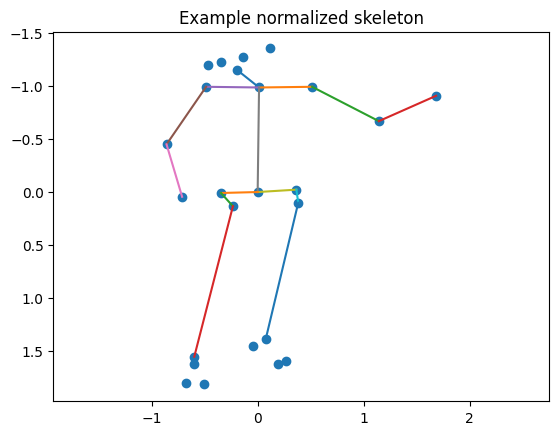

In [27]:
def plot_skeleton(keypoints, title="Skeleton"):
    pts = np.array(keypoints, dtype=float).reshape(-1, 2)   # 25 × 2

    x = pts[:, 0]
    y = -pts[:, 1]   # flip Y for correct orientation

    skeleton = [
        (0,1), (1,2), (2,3), (3,4),
        (1,5), (5,6), (6,7),
        (1,8),
        (8,9), (9,10), (10,11),
        (8,12), (12,13), (13,14),
    ]

    # plt.figure(figsize=(4,6))
    for a, b in skeleton:
        if x[a] != -1 and x[b] != -1:
            plt.plot([x[a], x[b]], [y[a], y[b]])
        
    graph = plt.scatter(x, y)
    plt.title(title)
    plt.gca().invert_yaxis() 

    plt.axis('equal')
    plt.show()
    return graph
sample = train_matrices[20].values[:,0]  
plot_skeleton(sample, "Example normalized skeleton")


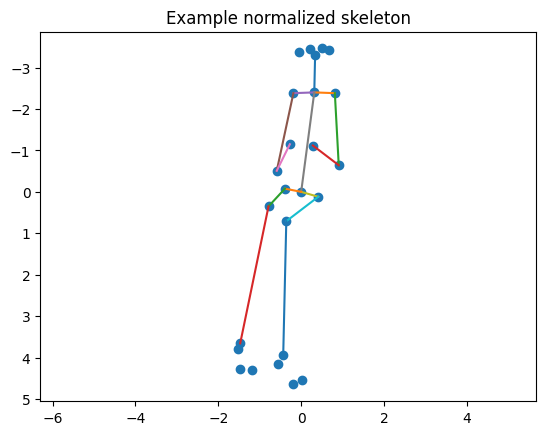

In [31]:
from IPython.display import clear_output

plt.figure(figsize=(8,6))
for i in range(0,74):
    sample = train_matrices[77].values[:,i]  
    graph = plot_skeleton(sample, "Example normalized skeleton")
    clear_output(wait=True)

In [19]:

#Concatenating according to body part arrangements - can look at "Body_25" for reference
left_arm_train_np = np.concatenate((train_tensor[:, 2:4, :], train_tensor[:, 10:16, :]), axis=1)
print(left_arm_train_np.shape)
right_arm_train_np = np.concatenate((train_tensor[:, 2:4, :], train_tensor[:, 4:10, :]), axis=1)
print(right_arm_train_np.shape)
left_leg_train_np = np.concatenate((train_tensor[:, 16:18, :], train_tensor[:, 24:30, :], train_tensor[:, 38:44, :]), axis=1)
print(left_leg_train_np.shape)
right_leg_train_np = np.concatenate((train_tensor[:, 16:24, :], train_tensor[:, 44:50, :]), axis=1)
print(right_leg_train_np.shape)
torso_train_np = np.concatenate((train_tensor[:, 0:4, :], train_tensor[:, 30:38, :]), axis=1)
print(torso_train_np.shape)

left_arm_test_np = np.concatenate((test_tensor[:, 2:4, :], test_tensor[:, 10:16, :]), axis=1)
print(left_arm_test_np.shape)
right_arm_test_np = np.concatenate((test_tensor[:, 2:4, :], test_tensor[:, 4:10, :]), axis=1)
print(right_arm_test_np.shape)
left_leg_test_np = np.concatenate((test_tensor[:, 16:18, :], test_tensor[:, 24:30, :], test_tensor[:, 38:44, :]), axis=1)
print(left_leg_test_np.shape)
right_leg_test_np = np.concatenate((test_tensor[:, 16:24, :], test_tensor[:, 44:50, :]), axis=1)
print(right_leg_test_np.shape)
torso_test_np = np.concatenate((test_tensor[:, 0:4, :], test_tensor[:, 30:38, :]), axis=1)
print(torso_test_np.shape)

left_arm_train_tensor = torch.from_numpy(left_arm_train_np).float()
right_arm_train_tensor = torch.from_numpy(right_arm_train_np).float()
left_leg_train_tensor = torch.from_numpy(left_leg_train_np).float()
right_leg_train_tensor = torch.from_numpy(right_leg_train_np).float()
torso_train_tensor = torch.from_numpy(torso_train_np).float()

left_arm_test_tensor = torch.from_numpy(left_arm_test_np).float()
right_arm_test_tensor = torch.from_numpy(right_arm_test_np).float()
left_leg_test_tensor = torch.from_numpy(left_leg_test_np).float()
right_leg_test_tensor = torch.from_numpy(right_leg_test_np).float()
torso_test_tensor = torch.from_numpy(torso_test_np).float()

#Spatiotemporal Co-Attention Recurrent Neural Networks for Human-Skeleton Motion Prediction explains travelling and surrounding sequences for improved information for RNN training.
rnn_sequence_train = np.concatenate((train_tensor[:, 2:4, :], right_leg_train_np, train_tensor[:, 20:22, :], train_tensor[:, 18:20, :], left_leg_train_np, train_tensor[:, 26:28, :], train_tensor[:, 24:26, :], train_tensor[:, 16:18, :], torso_train_np, right_arm_train_np, train_tensor[:, 6:8, :], train_tensor[:, 4:6, :], left_arm_train_np, train_tensor[:, 12:14, :], train_tensor[:, 10:12, :], train_tensor[:, 2:4, :]), axis=1)
rnn_sequence_train = np.array(rnn_sequence_train, dtype=float)
rnn_sequence_train_tensor = torch.from_numpy(rnn_sequence_train).float()
reshaped_rnn_train_tensor = rnn_sequence_train_tensor.permute(0, 2, 1)
print(reshaped_rnn_train_tensor.shape)

rnn_sequence_test = np.concatenate((test_tensor[:, 2:4, :], right_leg_test_np, test_tensor[:, 20:22, :], test_tensor[:, 18:20, :], left_leg_test_np, test_tensor[:, 26:28, :], test_tensor[:, 24:26, :], test_tensor[:, 16:18, :], torso_test_np, right_arm_test_np, test_tensor[:, 6:8, :], test_tensor[:, 4:6, :], left_arm_test_np, test_tensor[:, 12:14, :], test_tensor[:, 10:12, :], test_tensor[:, 2:4, :]), axis=1)
rnn_sequence_test = np.array(rnn_sequence_test, dtype=float)
rnn_sequence_test_tensor = torch.from_numpy(rnn_sequence_test).float()
reshaped_rnn_test_tensor = rnn_sequence_test_tensor.permute(0, 2, 1)
print(reshaped_rnn_test_tensor.shape)

train_batch_labels = train_batch_labels.long().view(-1)
labels_np = train_batch_labels.cpu().numpy()


train_dataset = TensorDataset(
    left_arm_train_tensor,
    right_arm_train_tensor,
    left_leg_train_tensor,
    right_leg_train_tensor,
    torso_train_tensor,
    reshaped_rnn_train_tensor,
    train_batch_labels
)


(454, 8, 75)
(454, 8, 75)
(454, 14, 75)
(454, 14, 75)
(454, 12, 75)
(137, 8, 75)
(137, 8, 75)
(137, 14, 75)
(137, 14, 75)
(137, 12, 75)
torch.Size([454, 75, 78])
torch.Size([137, 75, 78])


In [21]:
#This block illustrates all input data of the OpenPose json files.
stacked_np = np.concatenate((train_tensor, test_tensor), axis=0)
tensor = torch.from_numpy(stacked_np)
pairs = [
    ((1, 5), (5, 6), (6, 7)),                                    # Left Arm
    ((1, 2), (2, 3), (3, 4)),                                    # Right Arm
    ((8, 12), (12, 13), (13, 14), (14, 19), (19, 20), (20, 21)), # Left Leg
    ((8, 9), (9, 10), (10, 11), (11, 22), (22, 23), (23, 24)),   # Right Leg
    ((8, 1), (1, 0), (0, 15), (15, 17), (17, 16), (16, 18))      # Torso
]

colors = [
    (0, 255, 0),      # Green for left arm
    (255, 0, 0),      # Blue for right arm
    (0, 255, 255),    # Cyan for left leg
    (255, 255, 0),    # Yellow for right leg
    (255, 0, 255)     # Magenta for torso
]

def draw_stick_figure(image, keypoints, frame_width, frame_height):
    body_parts = ["left_arm", "right_arm", "left_leg", "right_leg", "torso"]

    for idx, part_connections in enumerate(pairs):
        for partA, partB in part_connections:
            if partA * 2 < len(keypoints) and partB * 2 < len(keypoints):
                if keypoints[partA * 2] >= 0 and keypoints[partB * 2] >= 0:  # If both keypoints are detected
                    x1 = int(keypoints[partA * 2] * frame_width)
                    y1 = int(keypoints[partA * 2 + 1] * frame_height)
                    x2 = int(keypoints[partB * 2] * frame_width)
                    y2 = int(keypoints[partB * 2 + 1] * frame_height)
                    color = colors[idx]
                    cv2.line(image, (x1, y1), (x2, y2), color, 2)
    return image

def create_stick_figure_video_from_tensor(tensor, output_video_path, frame_size=(640, 480), fps=25):
    os.makedirs(os.path.dirname(output_video_path), exist_ok=True)

    num_videos, num_keypoints, num_frames = tensor.shape
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')

    for video_idx in range(num_videos):
        out = cv2.VideoWriter(f"{output_video_path}_video_{video_idx}.mp4", fourcc, fps, frame_size)

        for frame_idx in range(num_frames):
            frame = np.zeros((frame_size[1], frame_size[0], 3), dtype=np.uint8)
            keypoints = tensor[video_idx, :, frame_idx]

            for i in range(0, num_keypoints, 2):
                if keypoints[i] >= 0 and keypoints[i + 1] >= 0:
                    cv2.circle(frame, (int(keypoints[i] * frame_size[0]), int(keypoints[i + 1] * frame_size[1])), 3, (255, 255, 255), -1)

            frame = draw_stick_figure(frame, keypoints, frame_size[0], frame_size[1])
            out.write(frame)

        out.release()
        print(f"Video {video_idx} saved at: {output_video_path}_video_{video_idx}.mp4")

output_directory = 'baseline2/videos'
output_video_path = f'{output_directory}/stick_figure'

create_stick_figure_video_from_tensor(tensor, output_video_path, frame_size=(640, 480), fps=25)

def display_video(video_path):
    mp4 = open(video_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML(f"""
    <video width=640 controls>
        <source src="{data_url}" type="video/mp4">
    </video>
    """)

video_path = f'{output_video_path}_video_0.mp4'
if os.path.exists(video_path):
    display_video(video_path)
else:
    print(f"Video file does not exist at: {video_path}")

Video 0 saved at: baseline2/videos/stick_figure_video_0.mp4
Video 1 saved at: baseline2/videos/stick_figure_video_1.mp4
Video 2 saved at: baseline2/videos/stick_figure_video_2.mp4
Video 3 saved at: baseline2/videos/stick_figure_video_3.mp4
Video 4 saved at: baseline2/videos/stick_figure_video_4.mp4
Video 5 saved at: baseline2/videos/stick_figure_video_5.mp4
Video 6 saved at: baseline2/videos/stick_figure_video_6.mp4
Video 7 saved at: baseline2/videos/stick_figure_video_7.mp4
Video 8 saved at: baseline2/videos/stick_figure_video_8.mp4
Video 9 saved at: baseline2/videos/stick_figure_video_9.mp4
Video 10 saved at: baseline2/videos/stick_figure_video_10.mp4
Video 11 saved at: baseline2/videos/stick_figure_video_11.mp4
Video 12 saved at: baseline2/videos/stick_figure_video_12.mp4
Video 13 saved at: baseline2/videos/stick_figure_video_13.mp4
Video 14 saved at: baseline2/videos/stick_figure_video_14.mp4
Video 15 saved at: baseline2/videos/stick_figure_video_15.mp4
Video 16 saved at: baseline2

In [50]:
class SelfAttention(nn.Module):
    def __init__(self, num_parts, input_dim):
        super(SelfAttention, self).__init__()
        self.num_parts = num_parts
        self.input_dim = input_dim
        self.query = nn.Linear(input_dim, input_dim)
        self.key = nn.Linear(input_dim, input_dim)
        self.value = nn.Linear(input_dim, input_dim)
        self.softmax = nn.Softmax(dim=2)

    def forward(self, x):
        # x is of shape [batch_size, num_parts, input_dim] (e.g., [318, 5, 128])
        queries = self.query(x)
        keys = self.key(x)
        values = self.value(x)

        # Compute attention scores across the body parts
        scores = torch.bmm(queries, keys.transpose(1, 2)) / (self.input_dim ** 0.5)
        attention_weights = self.softmax(scores)

        # Compute weighted sum of values based on attention weights
        weighted_values = torch.bmm(attention_weights, values)

        return weighted_values, scores, attention_weights


In [51]:
class TemporalSelfAttention(nn.Module):
    # https://arxiv.org/pdf/2202.02093
    # look at this paper and add TemporalAttention(Q,K,V,T)
    def __init__(self, num_parts, input_dim):
        super(SelfAttention, self).__init__()
        self.num_parts = num_parts
        self.input_dim = input_dim
        self.query = nn.Linear(input_dim, input_dim)
        self.key = nn.Linear(input_dim, input_dim)
        self.value = nn.Linear(input_dim, input_dim)
        self.softmax = nn.Softmax(dim=2)

    def forward(self, x):
        # x is of shape [batch_size, num_parts, input_dim] (e.g., [318, 5, 128])
        queries = self.query(x)
        keys = self.key(x)
        values = self.value(x)

        # Compute attention scores across the body parts
        scores = torch.bmm(queries, keys.transpose(1, 2)) / (self.input_dim ** 0.5)
        attention_weights = self.softmax(scores)

        # Compute weighted sum of values based on attention weights
        weighted_values = torch.bmm(attention_weights, values)

        return weighted_values, scores, attention_weights


In [52]:
"""
Temporal Attention Smoothin Techniques
attn shape: (B, T, T)
"""
def gaussian_smoothing(attn, kernel_size=5, sigma=1.0):
    coords = torch.arange(kernel_size) - kernel_size//2
    kernel = torch.exp(-(coords**2)/(2*sigma**2))
    kernel = kernel / kernel.sum()

    kernel = kernel.view(1,1,-1).to(attn.device)

    attn = attn.transpose(1,2)
    attn = F.conv1d(attn, kernel, padding=kernel_size//2)
    attn = attn.tranpose(1,2)

    return attn

def ema_smoothing(attn, alpha=0.8): 
    smoothed = attn.clone() 

    for t in range(1, attn.shape[1]):
        smoothed[:,t] = alpha*attn[:,t] + (1-alpha)*smoothed[:,t-1]

    return smoothed

def laplacian_loss(attn):
    diff = attn[:,1:,:] - attn[:,:-1,:]
    loss = (diff**2).mean()

    return loss 


In [53]:
num_nodes = 5
edges = []
for i in range(num_nodes):
    for j in range(num_nodes):
        if i != j:
            edges.append([i, j])

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
print(edge_index)

tensor([[0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4],
        [1, 2, 3, 4, 0, 2, 3, 4, 0, 1, 3, 4, 0, 1, 2, 4, 0, 1, 2, 3]])


In [54]:
# ablation flags 
spatial_ablation = False 
temporal_ablation = False

In [55]:
class ResidualBlock(nn.Module):
    def __init__(self, input_dim, output_dim, leaky_relu_alpha):
        super(ResidualBlock, self).__init__()
        self.fc = nn.Linear(input_dim, output_dim)
        self.bn = nn.BatchNorm1d(output_dim)
        self.leaky_relu = nn.LeakyReLU(negative_slope=leaky_relu_alpha)
        self.dropout = nn.Dropout(p=DROPOUT) # dropout_prob

        if input_dim != output_dim:
            self.residual_connection = nn.Linear(input_dim, output_dim)
        else:
            self.residual_connection = None

    def forward(self, x):
        residual = x
        out = self.fc(x)
        out = self.bn(out)
        out = self.leaky_relu(out)
        out = self.dropout(out)

        if self.residual_connection is not None:
            residual = self.residual_connection(residual)

        out += residual
        return out

class SpatialNetwork(nn.Module):
    def __init__(self, n_part, n_graph_out, frame_nos, leaky_relu_alpha):
        super(SpatialNetwork, self).__init__()

        self.n_part = n_part
        self.n_graph_out = n_graph_out
        self.frame_nos = frame_nos

        self.body_parts_fc = nn.ModuleDict({
            'arms': nn.Linear(8, n_part),
            'legs': nn.Linear(14, n_part),
            'torso': nn.Linear(12, n_part),
        })

        self.self_attn = SelfAttention(num_parts=5, input_dim=n_part)
        self.gcn1 = GCNConv(in_channels=n_part, out_channels=n_graph_out, aggr='max', bias=True)
        self.bn_gcn1 = nn.BatchNorm1d(n_graph_out)
        self.fc6 = ResidualBlock(n_graph_out * frame_nos, 512, leaky_relu_alpha)
        self.fc7 = ResidualBlock(512, 256, leaky_relu_alpha)

        self.training_attention_scores = []
        self.training_attention_weights = []

    def reset_attention_scores(self):
        self.training_attention_scores = []
        self.training_attention_weights = []

    def forward_body_part(self, x, part):
        x = self.body_parts_fc[part](x)
        x = F.leaky_relu(x)
        x = F.dropout(x, p=DROPOUT, training=self.training) # 0.5
        return x

    def forward(self, left_arm, right_arm, left_leg, right_leg, torso, edge_index, is_training=True):
        batch_size, features, seq_len = left_arm.shape

        outputs = torch.zeros((batch_size, seq_len, self.n_graph_out), device=left_arm.device)

        for t in range(seq_len):
            left_arm_out = self.forward_body_part(left_arm[:, :, t], 'arms')
            right_arm_out = self.forward_body_part(right_arm[:, :, t], 'arms')
            left_leg_out = self.forward_body_part(left_leg[:, :, t], 'legs')
            right_leg_out = self.forward_body_part(right_leg[:, :, t], 'legs')
            torso_out = self.forward_body_part(torso[:, :, t], 'torso')

            concatenated = torch.stack((left_arm_out, right_arm_out, left_leg_out, right_leg_out, torso_out), dim=1)

            attn_output, attn_scores, attn_weights = self.self_attn(concatenated)

            if is_training:
                self.training_attention_scores.append(attn_scores)
                self.training_attention_weights.append(attn_weights)

            batch_size, num_nodes, feature_dim = attn_output.shape
            attn_output = attn_output.reshape(batch_size * num_nodes, feature_dim)

            gcn_output = self.gcn1(attn_output, edge_index)
            gcn_output = self.bn_gcn1(gcn_output)
            gcn_output = F.leaky_relu(gcn_output)
            gcn_output = F.dropout(gcn_output, p=DROPOUT, training=self.training) # 0.5
            gcn_output = gcn_output.view(batch_size, num_nodes, -1)
            pooled_output = torch.max(gcn_output, dim=1)[0]

            outputs[:, t, :] = pooled_output

        flattened_outputs = outputs.view(batch_size, -1)
        fc6_output = self.fc6(flattened_outputs)
        fc7_output = self.fc7(fc6_output)

        return fc7_output
        
    def get_last_epoch_attention_scores(self):
        attention_scores = torch.cat(self.training_attention_scores, dim=0)

    def get_last_epoch_attention_weights(self):
        attention_weights = torch.cat(self.training_attention_weights, dim=0)


In [ ]:
class TemporalNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers, dropout_prob, leaky_relu_alpha):
        super(TemporalNetwork, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, bidirectional=True, batch_first=True, dropout=dropout_prob) 

        self.self_attn = SelfAttention(num_parts=75, input_dim=hidden_size * 2)
        
        # self.self_attn = SelfAttention(num_parts=75, input_dim=hidden_size) # unidirectional LSTM
        self.dropout = nn.Dropout(dropout_prob) 

        # self.fc1 = nn.Linear(hidden_size, output_size * input_size) # uni
        self.fc1 = nn.Linear(hidden_size * 2, output_size * input_size)

        self.bn1 = nn.BatchNorm1d(output_size * input_size)
        self.fc2 = nn.Linear(output_size * input_size, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.fc3 = ResidualBlock(512, 256, leaky_relu_alpha)

        self.stored_attention_scores = []
        self.stored_attention_weights = []

    def forward(self, x):
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(x.device)
        # h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device) # unidirectional LSTM
        # c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device) # unidirectional LSTM* 

        out, _ = self.lstm(x, (h0, c0))

        out, scores, weights = self.self_attn(out)

        self.stored_attention_scores.append(scores)
        self.stored_attention_weights.append(weights)

        out = self.dropout(out)
        out = self.fc1(out[:, -1, :])  # Use the last time step's output
        out = out.view(out.size(0), -1)

        out = self.bn1(out)
        out = F.leaky_relu(out)

        out = self.fc2(out)
        out = self.bn2(out)
        out = F.leaky_relu(out)
        out = self.dropout(out)

        out = self.fc3(out)

        return out

    def clear_attention_weights(self):
        self.stored_attention_scores = []
        self.stored_attention_weights = []

    def get_attention_scores(self):
        return self.stored_attention_scores

    def get_attention_weights(self):
        return self.stored_attention_weights


In [57]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, input_dim, num_heads=4):
        super(MultiHeadSelfAttention, self).__init__()
        assert input_dim % num_heads == 0, "input_dim must be divisible by num_heads"
        self.num_heads = num_heads
        self.head_dim = input_dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv_proj = nn.Linear(input_dim, input_dim * 3)
        self.fc_out = nn.Linear(input_dim, input_dim)

    def forward(self, x):
        batch_size, seq_length, input_dim = x.shape

        qkv = self.qkv_proj(x).reshape(batch_size, seq_length, self.num_heads, 3 * self.head_dim)
        q, k, v = qkv.chunk(3, dim=-1)

        q = q.permute(0, 2, 1, 3)
        k = k.permute(0, 2, 1, 3)
        v = v.permute(0, 2, 1, 3)

        attn_weights = (q @ k.transpose(-2, -1)) * self.scale
        attn_probs = F.softmax(attn_weights, dim=-1)

        attn_out = (attn_probs @ v).permute(0, 2, 1, 3).reshape(batch_size, seq_length, input_dim)
        return self.fc_out(attn_out)

class FinalConcatenation(nn.Module):
    def __init__(self, input_dim=512, output_dim=2, dropout_prob=DROPOUT, num_heads=4): # 0.5
        super(FinalConcatenation, self).__init__()
        self.attention = MultiHeadSelfAttention(input_dim=input_dim, num_heads=num_heads)
        self.fc1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.dropout = nn.Dropout(dropout_prob)
        self.fc2 = nn.Linear(256, output_dim)

        self.layer_norm = LayerNorm(input_dim)
        self.residual_fc = nn.Linear(input_dim, input_dim)

    def forward(self, x):
        x = x.unsqueeze(1)  # [batch_size, seq_length, input_dim] -> [batch_size, 1, input_dim]

        res = x
        x = self.layer_norm(x)
        x = self.attention(x)
        x += self.residual_fc(res)

        x = x.squeeze(1)  # [batch_size, input_dim]

        x = self.fc1(x)  # [batch_size, 256]
        x = self.bn1(x)
        x = F.leaky_relu(x)
        x = self.dropout(x)
        x = self.fc2(x)  # [batch_size, output_dim]
        x = F.log_softmax(x, dim=1)
        return x


In [58]:
def initialize_weights(model):
    for name, param in model.named_parameters():
        if 'weight' in name:
            if param.dim() >= 2:
                nn.init.kaiming_normal_(param.data, nonlinearity='leaky_relu')
            else:
                param.data.fill_(1)
        elif 'bias' in name:
            param.data.fill_(0)

In [59]:
class FullModel(torch.nn.Module):
    def __init__(self, spatial_net, temporal_net, final_model, edge_index):
        super().__init__()
        self.spatial_net = spatial_net
        self.temporal_net = temporal_net
        self.final_model = final_model
        self.edge_index = edge_index

    def forward(self, left_arm, right_arm, left_leg, right_leg, torso, rnn_x):
        spatial_out = self.spatial_net(left_arm, right_arm, left_leg, right_leg, torso, self.edge_index, is_training=False)
        temporal_out = self.temporal_net(rnn_x)
        concat = torch.cat([spatial_out, temporal_out], dim=1)
        logits = self.final_model(concat)
        return logits


In [73]:
# GradCAM
# https://arxiv.org/abs/1610.02391

class TemporalGradCAM:
    def __init__(self, full_model, temporal_net):
        self.full_model = full_model
        self.temporal_net = temporal_net
        self.activations = None
        self.gradients = None
        self.h_fwd = None
        self.h_bwd = None

    def _fwd_hook(self, module, inp, out):
        if isinstance(out, tuple):
            out = out[0]
        self.activations = out  
        if self.activations.requires_grad:
            self.activations.retain_grad()

    def _bwd_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]  

    def register(self):
        self.h_fwd = self.temporal_net.lstm.register_forward_hook(self._fwd_hook)
        self.h_bwd = self.temporal_net.lstm.register_full_backward_hook(self._bwd_hook)

    def remove(self):
        if self.h_fwd is not None: self.h_fwd.remove()
        if self.h_bwd is not None: self.h_bwd.remove()

    @torch.no_grad()
    def _normalize(self, x):
        return x / (x.max(dim=1, keepdim=True).values + 1e-8)

    def __call__(self, batch, target_class=None):
        """
        returns: cam_time [B, T]
        """
        left_arm, right_arm, left_leg, right_leg, torso, rnn_x, labels = batch

        self.full_model.zero_grad(set_to_none=True)
        self.temporal_net.zero_grad(set_to_none=True)

        out = self.full_model(left_arm, right_arm, left_leg, right_leg, torso, rnn_x)
        if target_class is None:
            target_class = out.argmax(dim=1)

        scores = out.gather(1, target_class.view(-1, 1)).squeeze(1)
        scores.sum().backward()

        A = self.activations       
        dYdA = self.gradients         
        if A is None or dYdA is None:
            raise RuntimeError("Hooks did not capture activations/gradients.")

        w = dYdA.mean(dim=1)

        cam = torch.relu((A * w.unsqueeze(1)).sum(dim=-1))

        cam = self._normalize(cam.detach())
        return cam

def plotHeatmap(all_cams, sort_index, boundary, sorted_labels, correct_flags, title, show="all"):
    cam_all = torch.cat(all_cams, dim=0)
    cam_np = cam_all.numpy()
    cam_np = cam_np[sort_index]   # sort heatmap rows by class

    sorted_labels = sorted_labels.copy()
    correct_sorted = correct_flags[sort_index]
    
    if show =="correct":
        mask = correct_sorted == 1
    elif show == "incorrect":
        mask = correct_sorted == 0
    else:
        mask = np.ones_like(correct_sorted, dtype=bool)

    cam_np = cam_np[mask]
    correct_sorted = correct_sorted[mask]
    sorted_labels = sorted_labels[mask]


    # correct_sorted = correct_flags[sort_index].reshape(-1, 1)

    boundary = np.sum(sorted_labels == 0) - 0.5

    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(13, 5),
        gridspec_kw={"width_ratios": [30, 1], "wspace": -0.16}
    )

    im = ax1.imshow(cam_np, aspect='auto', interpolation='nearest')
    ax1.axhline(boundary, color="white", linewidth=2)
    ax1.set_title(title)
    ax1.set_xlabel("Timestep")
    ax1.set_ylabel("Sample index")

    x_text = cam_np.shape[1] - 1
    ax1.text(x_text, boundary / 2, "Class 1", rotation=-90, va="center", ha="right", color="white")
    ax1.text(x_text, boundary + (len(sorted_labels) - boundary) / 2, "Class 0",
             rotation=-90, va="center", ha="right", color="white")

    cbar = fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
    cbar.set_label("Class Activation Strength")

    # Correct / incorrect side bar
    correctness_cmap = ListedColormap(["red", "green"])  # 0 = incorrect, 1 = correct
    ax2.imshow(correct_sorted.reshape(-1,1), aspect='auto', interpolation='nearest',
               cmap=correctness_cmap, vmin=0, vmax=1)
    ax2.axhline(boundary, color="white", linewidth=2)
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_title("Pred")

    plt.show()

In [61]:
# Saliency Maps 
"""
How sensitive the model's prediction is to small changes in the input at each timestep
"""
def saliency(full_model, batch, target_class=None, reduce="sum"):
    left_arm, right_arm, left_leg, right_leg, torso, rnn_x, labels = batch 

    rnn_x = rnn_x.clone().detach().requires_grad_(True)

    full_model.zero_grad(set_to_none=True)
    out = full_model(left_arm, right_arm, left_leg, right_leg, torso, rnn_x)

    if target_class is None:
        target_class = out.argmax(dim=1) 

    scores = out.gather(1, target_class.view(-1, 1)).squeeze(1) 
    scores.sum().backward()

    grad = rnn_x.grad.detach()

    if reduce == "sum":
        sal = grad.abs().sum(dim=-1)
    elif reduce == "max":
        sal = grad.abs().max(dim=-1).values
    else:
        raise ValueError("reduce must be 'sum' or 'max'")

    sal = sal / (sal.max(dim=1, keepdim=True).values + 1e-8)
    return sal



In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, verbose=False, delta=0, path=f'checkpoint.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = float('inf')
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, spatial_net, temporal_net, final_model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, spatial_net, temporal_net, final_model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, spatial_net, temporal_net, final_model)
            self.counter = 0

    def save_checkpoint(self, val_loss, spatial_net, temporal_net, final_model):
        '''Saves model when validation loss decrease.'''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        
        state = {
            'spatial' : spatial_net.state_dict(),
            'temporal' : temporal_net.state_dict(),
            'final' : final_model.state_dict(),
        }
        torch.save(state, self.path)
        self.val_loss_min = val_loss

# https://github.com/Bjarten/early-stopping-pytorch/blob/master/pytorchtools.py

In [63]:
def custom_initialize_weights(model, gcn_constant=0.0001):
    for name, module in model.named_modules():
        if isinstance(module, GCNConv):
            init.constant_(module.lin.weight, gcn_constant)
            if module.lin.bias is not None:
                init.constant_(module.lin.bias, 0)
        elif isinstance(module, SelfAttention):
            init.kaiming_normal_(module.query.weight, nonlinearity='leaky_relu')
            init.kaiming_normal_(module.key.weight, nonlinearity='leaky_relu')
            init.kaiming_normal_(module.value.weight, nonlinearity='leaky_relu')
            if module.query.bias is not None:
                init.constant_(module.query.bias, 0)
            if module.key.bias is not None:
                init.constant_(module.key.bias, 0)
            if module.value.bias is not None:
                init.constant_(module.value.bias, 0)
        elif isinstance(module, nn.Linear):
            init.kaiming_normal_(module.weight, nonlinearity='leaky_relu')
            if module.bias is not None:
                init.constant_(module.bias, 0)
        elif isinstance(module, nn.BatchNorm1d):
            init.constant_(module.weight, 1)
            init.constant_(module.bias, 0)

In [ ]:
leaky_relu_alpha = 0.01
input_size = 78
hidden_size = n_rnn
output_size = n_rnn_out
num_layers = 4

In [65]:
alpha=torch.tensor([0.02, 0.98])
gamma=2.5
dropout_prob = 0.3
learning_rate=0.0000075
weight_decay=0.001
lrMultiplier = 4

In [66]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=alpha, gamma=gamma, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(
            logits,
            targets,
            reduction="none"
        ) 

        pt = torch.exp(-ce_loss)  # pt = P(correct class)
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.alpha is not None: 
            alpha_t = self.alpha[targets]
            focal_loss = alpha_t * focal_loss

        if self.reduction == "mean":
            return focal_loss.mean()
        elif self.reduction == "sum":
            return focal_loss.sum()
        else:
            return focal_loss


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold
from scipy.stats import ttest_1samp
from torch.utils.data import DataLoader, Subset, TensorDataset

class_names = ['Class 1', 'Class 0']

def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

def bootstrap_confidence_interval(data, num_bootstrap_samples=1000, confidence_level=0.95):
    n = len(data)
    bootstrap_samples = np.random.choice(data, (num_bootstrap_samples, n), replace=True)
    bootstrap_means = np.mean(bootstrap_samples, axis=1)
    lower_bound = np.percentile(bootstrap_means, (1-confidence_level)/2 * 100)
    upper_bound = np.percentile(bootstrap_means, (1 + confidence_level)/2 * 100)

    return round(float(lower_bound), 4), round(float(upper_bound), 4)

def create_data_loader(dataset, indices, batch_size, shuffle=False, drop_last=False):
    subset = Subset(dataset, indices)
    return DataLoader(subset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last)

def calculate_metrics(all_labels, all_preds):
    cm = confusion_matrix(all_labels, all_preds)
    tp, fn, fp, tn = cm.ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    precision = tp / (tp + fp) if (tp + fp) != 0 else 0
    recall = sensitivity  # recall is the same as sensitivity
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    balanced_acc = 0.5 * (sensitivity + specificity)


    return accuracy, sensitivity, specificity, f1, balanced_acc


def train_model(alpha, gamma, learning_rate, weight_decay, train_loader, val_loader, edge_index, class_names,
                spatial_net, temporal_net, final_model, fold):
    def set_seeds(seed=42):
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        np.random.seed(seed)
        random.seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    # set_seeds(42)
    spatial_net = SpatialNetwork(n_part, n_graph_out, frame_nos, leaky_relu_alpha)
    custom_initialize_weights(spatial_net)

    temporal_net = TemporalNetwork(input_size, hidden_size, output_size, num_layers, dropout_prob, leaky_relu_alpha)
    initialize_weights(temporal_net)

    final_model = FinalConcatenation()
    initialize_weights(final_model)
    
    num_epochs = 150

    optimizer = optim.Adam(list(spatial_net.parameters()) + list(temporal_net.parameters()) + list(final_model.parameters()),
                           lr=learning_rate, weight_decay=weight_decay)
    steps_per_epoch = len(train_loader)
    step_size_up = 3 * steps_per_epoch
    print(step_size_up)
    scheduler = optim.lr_scheduler.CyclicLR(optimizer, base_lr=learning_rate, max_lr=learning_rate*lrMultiplier, step_size_up=step_size_up, mode='triangular2') # step size orig 2000

    early_stopping = EarlyStopping(patience=num_epochs+1, verbose=True, path=f'checkpoint_fold_{fold+1}.pt') # patience set to epochs because then early stopping doesnt occur but we still save the model
    
    criterion = FocalLoss(alpha=alpha, gamma=gamma)

    train_metrics = {'accuracy': [], 'sensitivity': [], 'specificity': [], 'f1': [], 'balanced_acc': []}
    val_metrics   = {'accuracy': [], 'sensitivity': [], 'specificity': [], 'f1': [], 'balanced_acc': []}


    valLossArray = []
    trainLossArray = []
    best_bal_acc = -1.0
    best_val_loss = 10

    for epoch in range(num_epochs):
        temporal_net.clear_attention_weights()

        spatial_net.train()
        temporal_net.train()
        final_model.train()

        all_train_preds = []
        all_train_labels = []

        for batch in train_loader:
            left_arm_train_tensor, right_arm_train_tensor, left_leg_train_tensor, right_leg_train_tensor, torso_train_tensor, reshaped_rnn_train_tensor, train_batch_labels = batch

            optimizer.zero_grad()
            if spatial_ablation:
                output_spatial_train = torch.zeros(32, 256)
            else:
                output_spatial_train = spatial_net(left_arm_train_tensor, right_arm_train_tensor, left_leg_train_tensor,
                                                    right_leg_train_tensor, torso_train_tensor, edge_index)
                
            if temporal_ablation:
                output_temporal_train = torch.zeros(32, 256)
            else:
                output_temporal_train = temporal_net(reshaped_rnn_train_tensor)
            concatenated_input_train = torch.cat((output_spatial_train, output_temporal_train), dim=1)
            final_output_train = final_model(concatenated_input_train)

            loss = criterion(final_output_train, train_batch_labels)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(spatial_net.parameters(), max_norm=1.0)
            torch.nn.utils.clip_grad_norm_(temporal_net.parameters(), max_norm=1.0)
            torch.nn.utils.clip_grad_norm_(final_model.parameters(), max_norm=1.0)

            optimizer.step()
            scheduler.step()

            _, train_preds = torch.max(final_output_train, 1)
            all_train_preds.extend(train_preds.cpu().numpy())
            all_train_labels.extend(train_batch_labels.cpu().numpy())


        train_accuracy, train_sensitivity, train_specificity, train_f1, train_balanced_acc = calculate_metrics(all_train_labels, all_train_preds)
        train_metrics['accuracy'].append(train_accuracy)
        train_metrics['sensitivity'].append(train_sensitivity)
        train_metrics['specificity'].append(train_specificity)
        train_metrics['f1'].append(train_f1)
        train_metrics['balanced_acc'].append(train_balanced_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}], Training Loss: {loss.item()}, Training Accuracy: {train_accuracy:.4f}, Training Sensitivity: {train_sensitivity:.4f}, Training Specificity: {train_specificity:.4f}, Training F1: {train_f1:.4f}, Training Bal Acc: {train_balanced_acc:.4f}")
        trainLossArray.append(loss.item())
        spatial_net.eval()
        temporal_net.eval()
        final_model.eval()

        temporal_net.clear_attention_weights()

        all_val_preds = []
        all_val_labels = []
        val_loss = 0.0

        with torch.no_grad():
            for batch in val_loader:
                left_arm_val_tensor, right_arm_val_tensor, left_leg_val_tensor, right_leg_val_tensor, torso_val_tensor, reshaped_rnn_val_tensor, val_batch_labels = batch
                if spatial_ablation: 
                    output_spatial_val = torch.zeros(32, 256)
                else:
                    output_spatial_val = spatial_net(left_arm_val_tensor, right_arm_val_tensor, left_leg_val_tensor,
                                                    right_leg_val_tensor, torso_val_tensor, edge_index)

                if temporal_ablation:
                    output_temporal_val = torch.zeros(32,256)
                else:
                    output_temporal_val = temporal_net(reshaped_rnn_val_tensor)

                concatenated_input_val = torch.cat((output_spatial_val, output_temporal_val), dim=1)
                final_output_val = final_model(concatenated_input_val)

                val_loss += criterion(final_output_val, val_batch_labels).item()

                _, val_preds = torch.max(final_output_val, 1)
                all_val_preds.extend(val_preds.cpu().numpy())
                all_val_labels.extend(val_batch_labels.cpu().numpy())


        # Calculate metrics for validation
        val_accuracy, val_sensitivity, val_specificity, val_f1, val_balanced_acc = calculate_metrics(all_val_labels, all_val_preds)
        val_metrics['accuracy'].append(val_accuracy)
        val_metrics['sensitivity'].append(val_sensitivity)
        val_metrics['specificity'].append(val_specificity)
        val_metrics['f1'].append(val_f1)
        val_metrics['balanced_acc'].append(val_balanced_acc)


        print(f"Epoch [{epoch+1}/{num_epochs}], Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}, Validation Sensitivity: {val_sensitivity:.4f}, Validation Specificity: {val_specificity:.4f}, Validation F1: {val_f1:.4f}, Validation Bal Acc: {val_balanced_acc:.4f}")
        valLossArray.append(val_loss)


        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(
                {
                    'spatial': spatial_net.state_dict(),
                    'temporal': temporal_net.state_dict(),
                    'final': final_model.state_dict(),
                    'epoch': epoch,
                    'val_loss': best_val_loss
                },
                f'checkpoint_fold_{fold+1}.pt'
            )
            print(f"Saved new best model for fold {fold+1} at epoch {epoch+1} with Validation Loss={best_val_loss:.4f}")
        

    # Return all five values: validation loss, accuracy, sensitivity, specificity, and F1
    final_val_accuracy = val_metrics['accuracy'][-1]
    final_val_sensitivity = val_metrics['sensitivity'][-1]
    final_val_specificity = val_metrics['specificity'][-1]
    final_val_f1 = val_metrics['f1'][-1]

    best_epoch = int(np.argmax(val_metrics['balanced_acc']))

    best_val_accuracy = val_metrics['accuracy'][best_epoch]
    best_val_sensitivity = val_metrics['sensitivity'][best_epoch]
    best_val_specificity = val_metrics['specificity'][best_epoch]
    best_val_f1 = val_metrics['f1'][best_epoch]
    # best_val_balanced_acc = val_metrics['balanced_acc'][best_epoch]



    return valLossArray, best_val_accuracy, best_val_sensitivity, best_val_specificity, best_val_f1, best_bal_acc, trainLossArray


def cross_val_significance_test(dataset, labels, n_splits, batch_size, alpha, gamma, learning_rate, weight_decay,
                                edge_index, class_names, spatial_net, temporal_net, final_model, baseline=None):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    accuracies, sensitivities, specificities, f1_scores, balanced_accuracy_scores = [], [], [], [], []

    plt.figure(figsize=(18, 10))

    for fold, (train_index, test_index) in enumerate(skf.split(np.zeros(len(labels)), labels)):
        # set_seeds(42)
        print(f"Processing fold {fold + 1}/{n_splits}...")
        

        train_loader = create_data_loader(dataset, train_index, batch_size, shuffle=True, drop_last=True)
        test_loader = create_data_loader(dataset, test_index, batch_size, shuffle=False, drop_last=False)

        val_loss, accuracy, sensitivity, specificity, f1, balanced_acc, train_loss = train_model(
            alpha=alpha,
            gamma=gamma,
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            train_loader=train_loader,
            val_loader=test_loader,
            edge_index=edge_index,
            class_names=class_names,
            spatial_net=spatial_net,
            temporal_net=temporal_net,
            final_model=final_model,
            fold=fold
        )
        accuracies.append(accuracy)
        sensitivities.append(sensitivity)
        specificities.append(specificity)
        f1_scores.append(f1)
        balanced_accuracy_scores.append(balanced_acc)

        print(f"Fold {fold + 1}: Accuracy: {accuracy:.4f}, Sensitivity: {sensitivity:.4f}, Specificity: {specificity:.4f}, F1: {f1:.4f}")
        
        plt.subplot(2,3,fold+1)
        plt.plot(train_loss, label="Train Loss")
        plt.plot(val_loss, label="Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.title(f"Fold {fold+1}")

    # Calculate mean values for each metric directly from stored values
    mean_accuracy = np.mean(accuracies)
    mean_sensitivity = np.mean(sensitivities)
    mean_specificity = np.mean(specificities)
    mean_f1 = np.mean(f1_scores)
    mean_bal_acc = np.mean(balanced_accuracy_scores)

    # Calculate confidence intervals for each metric
    ci_accuracy = bootstrap_confidence_interval(accuracies)
    ci_sensitivity = bootstrap_confidence_interval(sensitivities)
    ci_specificity = bootstrap_confidence_interval(specificities)
    ci_f1 = bootstrap_confidence_interval(f1_scores)
    ci_bal_acc = bootstrap_confidence_interval(balanced_accuracy_scores)

    # Calculate standard deviations for all metrics
    std_accuracy = np.std(accuracies)
    std_sensitivity = np.std(sensitivities)
    std_specificity = np.std(specificities)
    std_f1 = np.std(f1_scores)
    std_bal_acc = np.std(balanced_accuracy_scores)

    # Calculate p-values if baseline is provided
    if baseline is not None:
        p_accuracy = ttest_1samp(accuracies, baseline).pvalue
        p_sensitivity = ttest_1samp(sensitivities, baseline).pvalue
        p_specificity = ttest_1samp(specificities, baseline).pvalue
        p_f1 = ttest_1samp(f1_scores, baseline).pvalue
        p_bal_acc = ttest_1samp(balanced_accuracy_scores, baseline).pvalue
    else:
        p_accuracy = p_sensitivity = p_specificity = p_f1 = p_bal_acc = None

    # Print results with the specified format
    print(f"Mean Accuracy: {mean_accuracy:.4f}, CI: {ci_accuracy}, p-value: {p_accuracy:.4f}" if p_accuracy is not None else f"Mean Accuracy: {mean_accuracy:.4f}, CI: {ci_accuracy}, p-value: None")
    print(f"Mean Sensitivity: {mean_sensitivity:.4f}, CI: {ci_sensitivity}, p-value: {p_sensitivity:.4f}" if p_sensitivity is not None else f"Mean Sensitivity: {mean_sensitivity:.4f}, CI: {ci_sensitivity}, p-value: None")
    print(f"Mean Specificity: {mean_specificity:.4f}, CI: {ci_specificity}, p-value: {p_specificity:.4f}" if p_specificity is not None else f"Mean Specificity: {mean_specificity:.4f}, CI: {ci_specificity}, p-value: None")
    print(f"Mean F1 Score: {mean_f1:.4f}, CI: {ci_f1}, p-value: {p_f1:.4f}" if p_f1 is not None else f"Mean F1 Score: {mean_f1:.4f}, CI: {ci_f1}, p-value: None")
    print(f"Mean Balanced Accuracy: {mean_bal_acc:.4f}, CI: {ci_bal_acc}, p-value: {p_bal_acc:.4f}" if p_bal_acc is not None else f"Mean Balanced Accuracy: {mean_bal_acc:.4f}, CI: {ci_bal_acc}, p-value: None")

    return (mean_accuracy, ci_accuracy, p_accuracy, std_accuracy,
            mean_sensitivity, ci_sensitivity, p_sensitivity, std_sensitivity,
            mean_specificity, ci_specificity, p_specificity, std_specificity,
            mean_f1, ci_f1, p_f1, std_f1, 
            mean_bal_acc, ci_bal_acc, p_bal_acc, std_bal_acc)

In [ ]:
"""
k-fold training, n_splits = number of folds
"""
# Train the models globally
spatial_net = SpatialNetwork(n_part, n_graph_out, frame_nos, leaky_relu_alpha)
temporal_net = TemporalNetwork(input_size, hidden_size, output_size, num_layers, dropout_prob, leaky_relu_alpha)
final_model = FinalConcatenation()

# Initialize the models
custom_initialize_weights(spatial_net)
initialize_weights(temporal_net)
initialize_weights(final_model)

# Example usage
dataset = TensorDataset(left_arm_train_tensor, right_arm_train_tensor, left_leg_train_tensor,
                        right_leg_train_tensor, torso_train_tensor, reshaped_rnn_train_tensor, train_batch_labels)

mean_accuracy, ci_accuracy, p_accuracy, std_accuracy, mean_sensitivity, ci_sensitivity, p_sensitivity, std_sensitivity, mean_specificity, ci_specificity, p_specificity, std_specificity, mean_f1, ci_f1, p_f1, std_f1, mean_bal_acc, ci_bal_acc, p_bal_acc, std_bal_acc = cross_val_significance_test(
    dataset=dataset,
    labels=train_batch_labels,
    n_splits=5,
    batch_size=32,
    baseline=0.5,
    alpha=alpha,
    gamma=gamma,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    edge_index=edge_index,
    class_names=class_names,
    spatial_net=spatial_net,
    temporal_net=temporal_net,
    final_model=final_model
)

print(f"Mean Accuracy: {mean_accuracy:.4f}, Std: {std_accuracy:.4f}, CI: {ci_accuracy}, p-value: {p_accuracy:.4f}")
print(f"Mean Sensitivity: {mean_sensitivity:.4f}, Std: {std_sensitivity:.4f}, CI: {ci_sensitivity}, p-value: {p_sensitivity:.4f}")
print(f"Mean Specificity: {mean_specificity:.4f}, Std: {std_specificity:.4f}, CI: {ci_specificity}, p-value: {p_specificity:.4f}")
print(f"Mean F1 Score: {mean_f1:.4f}, Std: {std_f1:.4f}, CI: {ci_f1}, p-value: {p_f1:.4f}")
print(f"Mean Balanced Accuracy: {mean_bal_acc:.4f}, Std: {std_bal_acc:.4f}, CI: {ci_bal_acc}, p-value: {p_bal_acc:.4f}")

Test Metrics
Accuracy: 0.8248
Sensitivity: 0.8738
Specificity: 0.6765
F1 Score: 0.8824
Balanced Accuracy: 0.7751


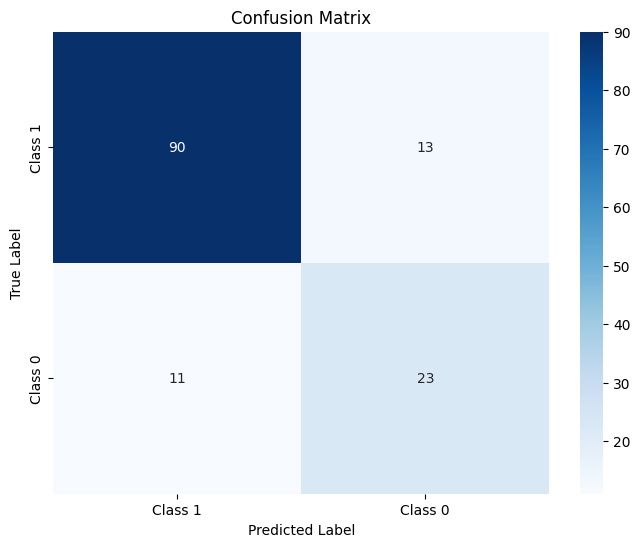

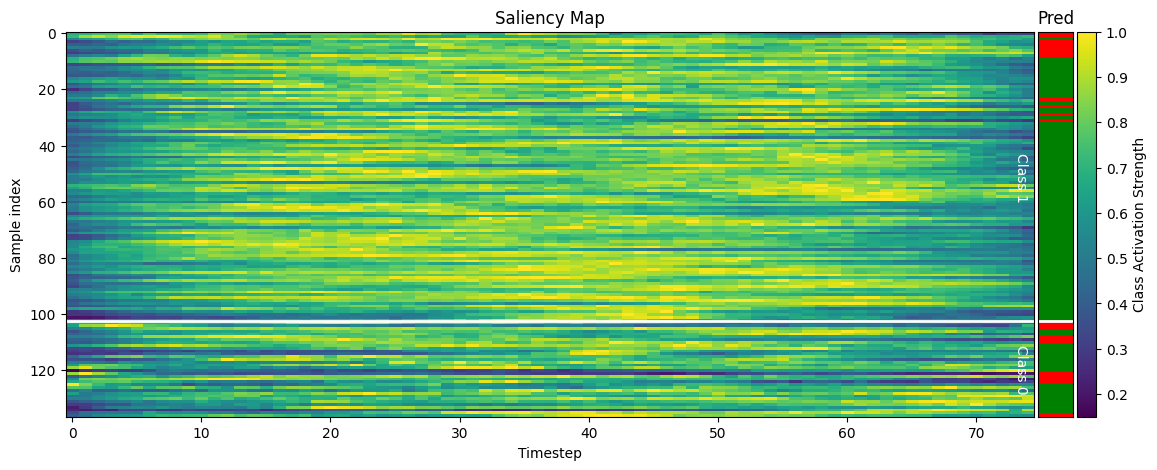

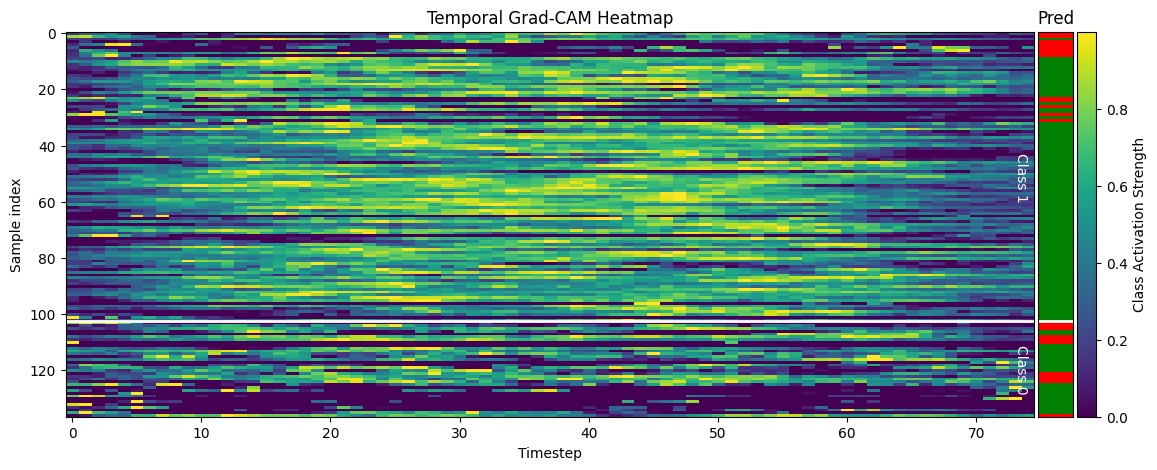

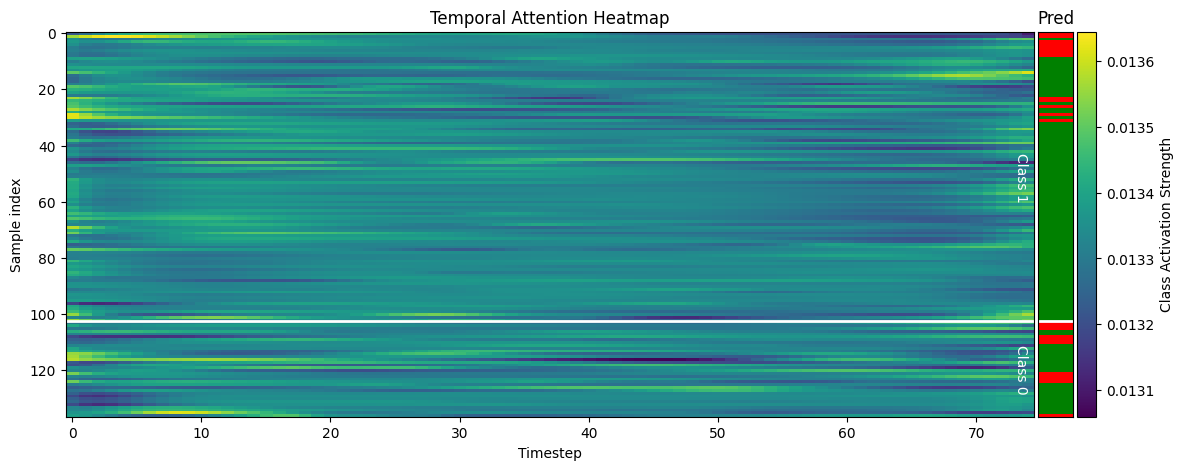

In [ ]:
from matplotlib.colors import ListedColormap

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load("checkpoint_fold_1.pt", map_location=device, weights_only=False)

spatial_net = SpatialNetwork(n_part, n_graph_out, frame_nos, leaky_relu_alpha).to(device)
temporal_net = TemporalNetwork(input_size, hidden_size, output_size, num_layers, dropout_prob, leaky_relu_alpha).to(device)
final_model = FinalConcatenation().to(device)

spatial_net.load_state_dict(checkpoint['spatial'])
temporal_net.load_state_dict(checkpoint['temporal'])
final_model.load_state_dict(checkpoint['final'])

spatial_net.eval()
temporal_net.eval()
final_model.eval()

test_dataset = TensorDataset(
    left_arm_test_tensor,
    right_arm_test_tensor,
    left_leg_test_tensor,
    right_leg_test_tensor,
    torso_test_tensor,
    reshaped_rnn_test_tensor,
    test_batch_labels
)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, drop_last=False)

edge_index_device = edge_index.to(device)

full_model = FullModel(spatial_net, temporal_net, final_model, edge_index_device).to(device)
full_model.eval()

cam_extractor = TemporalGradCAM(full_model, temporal_net)
cam_extractor.register()

temporal_net.clear_attention_weights()

all_test_preds = []
all_test_labels = []
all_attn = []
all_cams = []
all_saliency = []

results = []
sample_counter = 0

for batch in test_loader:
    batch = tuple(x.to(device) for x in batch)
    
    cam_extractor.register()
    was_lstm_training = temporal_net.lstm.training
    temporal_net.lstm.train()

    try:
        with torch.enable_grad():
            cam_time = cam_extractor(batch) 
            sal = saliency(full_model, batch)
    finally:
        temporal_net.lstm.train(was_lstm_training)
        cam_extractor.remove()

    all_cams.append(cam_time.detach().cpu())
    all_saliency.append(sal.detach().cpu())

    temporal_net.clear_attention_weights()
    (left_arm_batch, right_arm_batch, left_leg_batch, right_leg_batch, torso_batch, rnn_batch, labels_batch) = batch

    with torch.no_grad():
        spatial_out  = spatial_net(left_arm_batch, right_arm_batch, left_leg_batch, right_leg_batch, torso_batch, edge_index_device)
        temporal_out = temporal_net(rnn_batch)

        weights = temporal_net.get_attention_weights()[-1]
        att_curve = weights[:,-1,:]
        all_attn.append(att_curve.cpu())

        concatenated = torch.cat((spatial_out, temporal_out), dim=1)
        outputs = final_model(concatenated)

        _, preds = torch.max(outputs, 1)

        conf = outputs.exp().max(dim=1).values

    all_test_preds.extend(preds.cpu().numpy())
    all_test_labels.extend(labels_batch.cpu().numpy())

    batch_size_actual = labels_batch.size(0)
    
    for i in range(batch_size_actual):
        sample_idx = sample_counter + i
        meta = test_batch_metadata[sample_idx]

        results.append({
            "sample_idx": sample_idx,
            "directory": meta["directory"],
            "split_idx": meta["split_idx"],
            "start_file": meta["start_file"],
            "end_file": meta["end_file"],
            "augmentation": meta["augmentation"],
            "true_label": int(labels_batch[i].item()),
            "pred_label": int(preds[i].item()),
            "correct": int(preds[i].item() == labels_batch[i].item()),
            "confidence": float(conf[i].item())
        })

    sample_counter += batch_size_actual

accuracy, sensitivity, specificity, f1, balanced_acc = calculate_metrics(all_test_labels, all_test_preds)

print("Test Metrics")
print(f"Accuracy: {accuracy:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")

cm = confusion_matrix(all_test_labels, all_test_preds)
plot_confusion_matrix(cm, class_names)

results_df = pd.DataFrame(results)
results_df["true_class"] = results_df["true_label"].map({0: "Class 0", 1: "Class 1"})
results_df["pred_class"] = results_df["pred_label"].map({0: "Class 0", 1: "Class 1"})
results_df.to_csv("test_sample_results.csv", index=False)

sort_index = np.argsort(all_test_labels)
sorted_labels = np.array(all_test_labels)[sort_index]
boundary = np.sum(sorted_labels == 0)

correct_flags = (np.array(all_test_preds) == np.array(all_test_labels)).astype(int)
sorted_correct_flags = correct_flags[sort_index]
plotHeatmap(all_saliency, sort_index, boundary, sorted_labels, correct_flags, "Saliency Map") # Saliency Maps 
plotHeatmap(all_cams, sort_index, boundary, sorted_labels, correct_flags, "Temporal Grad-CAM Heatmap") # Grad-CAM
plotHeatmap(all_attn, sort_index, boundary, sorted_labels, correct_flags, "Temporal Attention Heatmap") #Attn Maps 